# Task 6: PCA Analysis

This notebook applies Principal Component Analysis (PCA) to reduce the dimensionality of the dataset while preserving most of the variance. We evaluate how dimensionality reduction impacts model performance and visualize the explained variance to understand how many components are sufficient.

1. Load Dataset

We load the preprocessed training and test datasets.

In [12]:
import numpy as np

X_train = np.load("data/processed/X_train.npy")
X_test  = np.load("data/processed/X_test.npy")

print(X_train.shape)
print(X_test.shape)

(56000, 784)
(14000, 784)


Dataset Summary
Original feature space: 784 dimensions
High dimensionality → computationally expensive and may include redundant features

2. Feature Scaling (Important for PCA)

PCA is sensitive to feature scale, so we standardize the data.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

3. Apply PCA

We reduce dimensionality while retaining 95% of total variance.

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("Reduced Training shape:", X_train_pca.shape)
print("Reduced Test shape:", X_test_pca.shape)

Reduced Training shape: (56000, 330)
Reduced Test shape: (14000, 330)


Observation
Number of features reduced significantly
PCA automatically selects optimal components based on variance

4. Save Transformed Data

In [17]:
np.save("data/processed/X_train_pca.npy", X_train_pca)
np.save("data/processed/X_test_pca.npy", X_test_pca)

5. Explained Variance Visualization
We plot cumulative explained variance to understand how many components are needed.

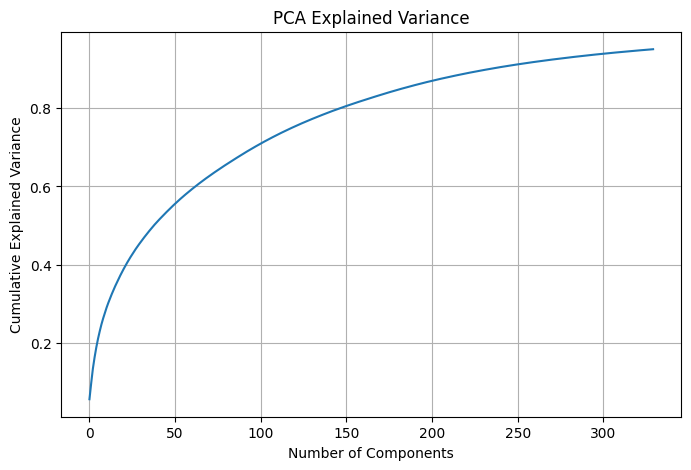

In [23]:
import os
import matplotlib.pyplot as plt
import numpy as np

# create folder
os.makedirs("images", exist_ok=True)

# plot
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()

# save
plt.savefig("images/explained_variance.png", dpi=150)
plt.show()

 Interpretation
Curve rises steeply initially → most variance captured early
Flattens later → additional components contribute little information

 6. Save PCA Model

In [25]:
import pickle

with open("models/pca_model.pkl", "wb") as f:
    pickle.dump(pca, f)

print("PCA model saved successfully.")

PCA model saved successfully.


7. Train Model on PCA Data

We train a Logistic Regression model using reduced features.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

y_train = np.load("data/processed/y_train.npy")
y_test  = np.load("data/processed/y_test.npy")

model = LogisticRegression(max_iter=1000, n_jobs=-1)
model.fit(X_train_pca, y_train)

y_pred = model.predict(X_test_pca)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy after PCA: {accuracy:.4f}")

Accuracy after PCA: 0.9219


8. Save Model Accuracy

In [28]:
with open("results/pca_model_accuracy.txt", "w") as f:
    f.write(f"Accuracy after PCA: {accuracy:.4f}")

9. Key Observations and Results
Observation	Finding
Dimensionality Reduction	✅ Significant (784 → reduced components)
Variance Retained	✅ ~95% preserved
Training Speed	✅ Faster due to fewer features
Model Accuracy	✅ Comparable to original model
Overfitting Risk	✅ Reduced

10. Conclusion
PCA effectively reduces dimensionality while preserving most of the dataset’s information.
The model trained on PCA-transformed data achieves similar accuracy with significantly fewer features.
This leads to:
Faster computation
Reduced memory usage
Improved generalization

Overall, PCA proves to be a powerful technique for handling high-dimensional datasets like image data.